In [ ]:
import numpy as np
import pandas as pd

dataset_name = "CTD5G"

graph_df_test = pd.read_csv('./processed_data/{}_test/ml_{}_test.csv'.format(dataset_name, dataset_name))
# edge_raw_features = np.load('./processed_data/{}_test/ml_{}_test.npy'.format(dataset_name, dataset_name))
# node_raw_features = np.load('./processed_data/{}_test/ml_{}_test_node.npy'.format(dataset_name, dataset_name))

# model = "GraphMixer"

# embeddings = np.load('./old/embeddings/{}.npy'.format(model))
# losses     = np.load('./old/losses/{}.npy'.format(model))

In [ ]:
from utils.DataLoader import get_idx_data_loader, get_link_prediction_data, get_reconstruction_data
from utils.utils import get_neighbor_sampler, NegativeEdgeSampler

node_raw_features, edge_raw_features, full_data, train_data, test_data = \
    get_reconstruction_data(dataset_name="old_CTD5G", val_ratio=0, test_ratio=0)

# initialize training neighbor sampler to retrieve temporal graph
train_neighbor_sampler = get_neighbor_sampler(data=train_data, sample_neighbor_strategy="recent",
                                                time_scaling_factor=1, seed=1)


train_len = int(len(train_data.src_node_ids) * 0.8)
train_idx_data_loader = get_idx_data_loader(indices_list=list(range(train_len)), batch_size=200, shuffle=False)

len(train_idx_data_loader) # 6998


FileNotFoundError: [Errno 2] No such file or directory: './processed_data/old_CTD5G_test_test/ml_old_CTD5G_test_test.csv'

In [17]:
from utils.utils import  NegativeEdgeSampler
from utils.DataLoader import get_idx_data_loader, get_reconstruction_data

dataset_name = "CTD5G"

node_raw_features, edge_raw_features, full_data, train_data, test_data = \
        get_reconstruction_data(dataset_name=dataset_name, val_ratio=0, test_ratio=0)

train_neg_edge_sampler = NegativeEdgeSampler(src_node_ids=train_data.src_node_ids, dst_node_ids=train_data.dst_node_ids, interact_times=train_data.node_interact_times, negative_sample_strategy="simple_inductive", seed=1)

train_idx_data_loader = get_idx_data_loader(indices_list=list(range(len(train_data.src_node_ids))), batch_size=80, shuffle=False)
for batch_idx, train_data_indices in enumerate(train_idx_data_loader):
    
    train_data_indices = train_data_indices.numpy()
    
    batch_src_node_ids, batch_dst_node_ids, batch_node_interact_times, batch_edge_ids, batch_node_pids, batch_attacks = \
                    train_data.src_node_ids[train_data_indices], train_data.dst_node_ids[train_data_indices], \
                    train_data.node_interact_times[train_data_indices], train_data.edge_ids[train_data_indices], train_data.packet_id[train_data_indices], train_data.attack_type[train_data_indices]
    
    batch_neg_src_node_ids, batch_neg_dst_node_ids = train_neg_edge_sampler.sample(
        size=len(batch_src_node_ids),
        batch_src_node_ids=batch_src_node_ids,
        batch_dst_node_ids=batch_dst_node_ids,
        current_batch_start_time=min(batch_node_interact_times),
        current_batch_end_time=max(batch_node_interact_times)
    )
    
    if batch_idx > 10:
        break

The dataset has 6515767 interactions, involving 1598081 different nodes
The training dataset has 4133505 interactions, involving 1048225 different nodes


In [2]:
import json

node_label_mapping = json.load(open('node_label_mapping.json', 'r'))
# node_label_mapping

In [14]:
node_label_mapping["100"]

'nudm-sdm'

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_graph(nx_graph, node_colors, node_labels):
    pos = nx.spring_layout(nx_graph, seed=42)

    edge_colors = [nx_graph[u][v]['color'] for u, v in nx_graph.edges()]
    node_color_list = [node_colors.get(n, "blue") for n in nx_graph.nodes()]

    plt.figure(figsize=(16, 14))

    nx.draw(
        nx_graph,
        pos,
        with_labels=False,
        edge_color=edge_colors,
        node_color=node_color_list,
        node_size=50,
        width=3,
    )

    # 🔥 labels uniquement pour sources
    nx.draw_networkx_labels(
        nx_graph,
        pos,
        labels=node_labels,
        font_size=6,
        font_color="gray"
    )

    # 🔥 garder seulement les edges avec forte loss
    edge_labels = {
        (u, v): data["label"]
        for u, v, data in nx_graph.edges(data=True)
        if data.get("loss", 0) > 0.2
    }

    nx.draw_networkx_edge_labels(
        nx_graph,
        pos,
        edge_labels=edge_labels,
        font_size=6
    )

    plt.title("Graph with Loss Gradient (Green → Red)")
    plt.axis("off")
    # plt.savefig(save_dir)

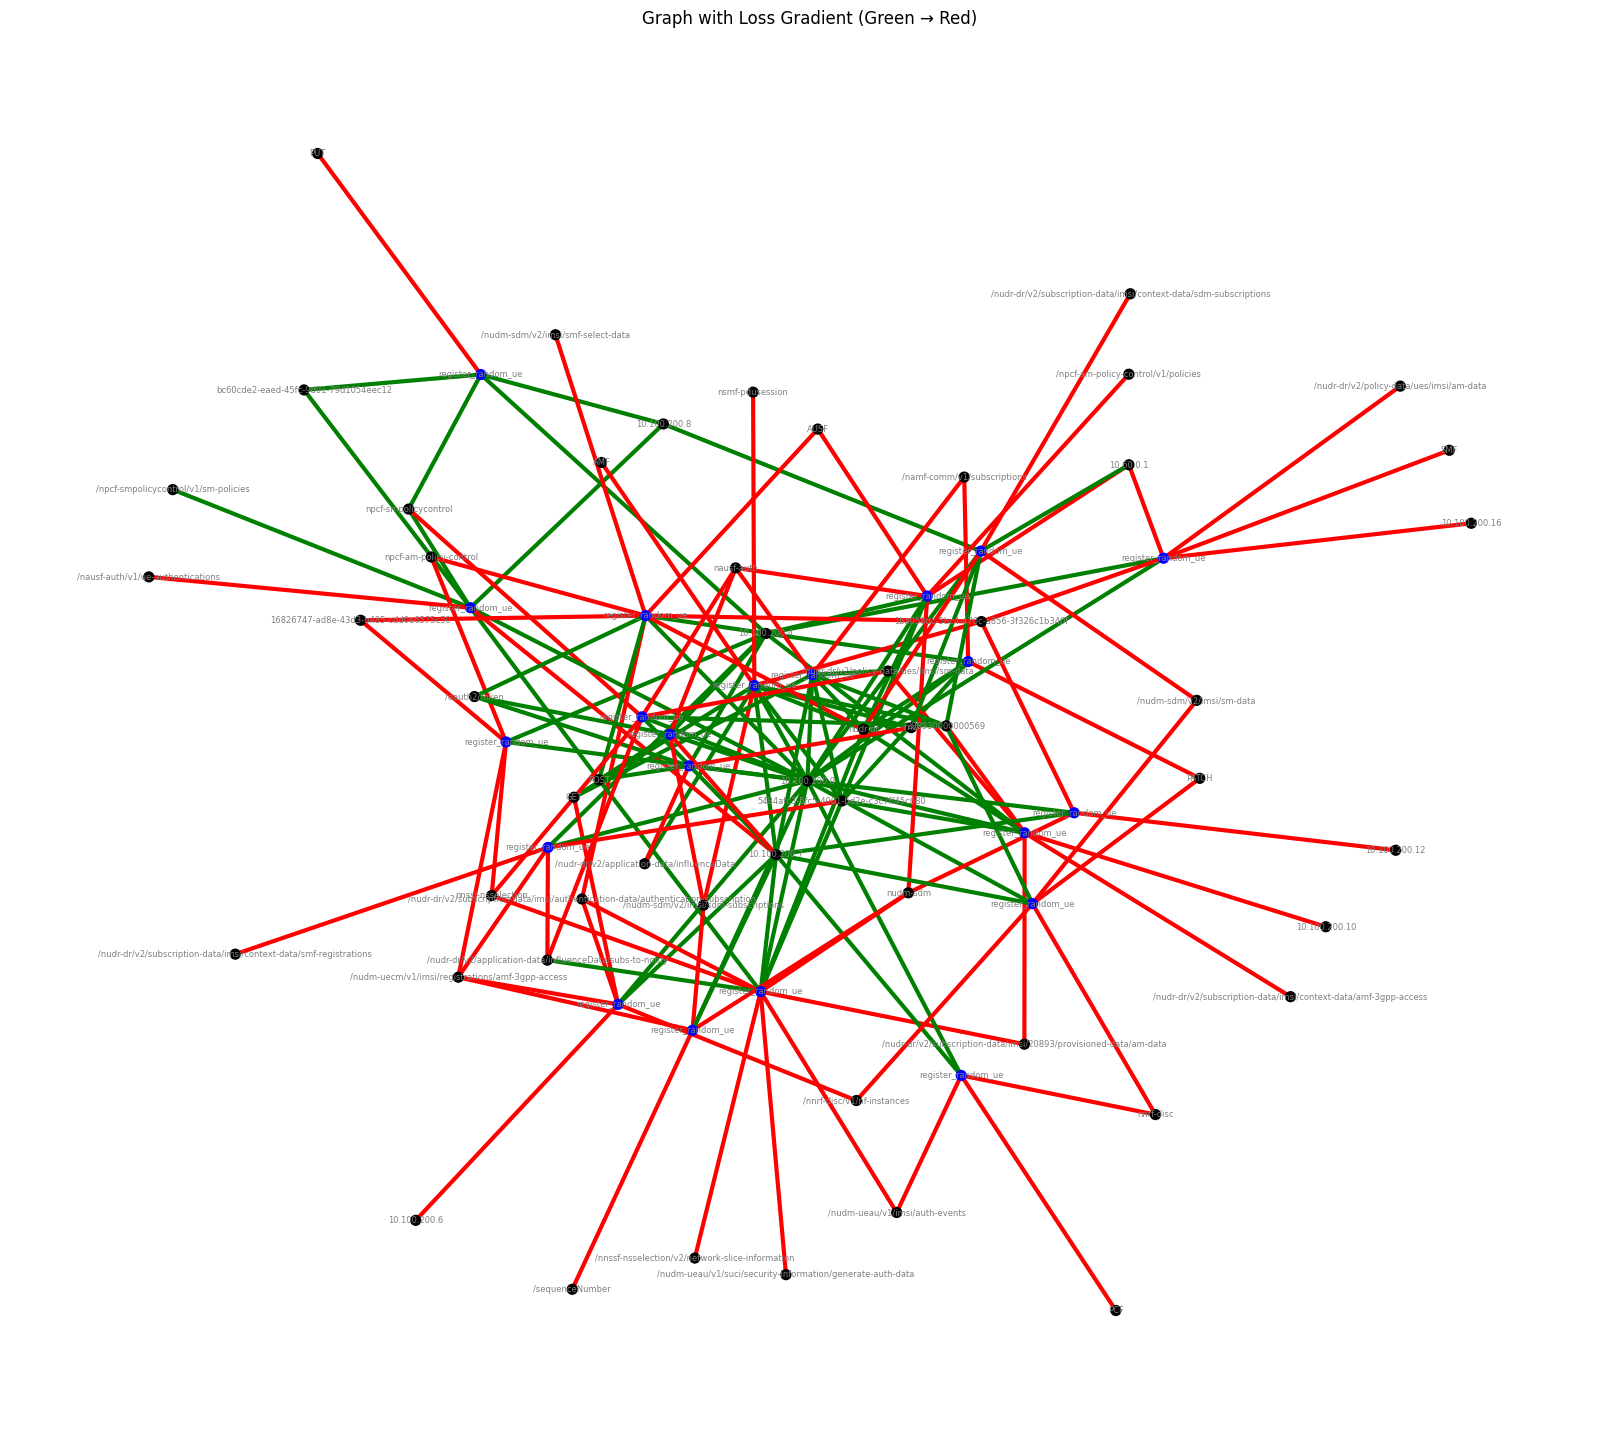

In [20]:

feature_vocab = {'http2.path': 0, 'pfcp.seid': 1, 'pfcp.f_teid.teid': 2, 'gtp.ext_hdr.pdu_ses_con.pdu_type': 3, 'http2.ausfInstanceId': 4, 'http2.ueId': 5, 'http2.imsi': 6, 'http2.amfInstanceId': 7, 'http2.cause': 8, 'http2.service-names': 9, 'http2.target-nf-type': 10, 'pfcp.apply_action.forw': 11, 'ip_src': 12, 'pfcp.msg_type': 13, 'pfcp.outer_hdr_creation.teid': 14, 'http2.nfInstanceId': 15, 'http2.target-nf-instance-id': 16, 'http2.supis': 17, 'gtp.teid': 18, 'pfcp.f_teid.ipv4_addr': 19, 'http2.ipv4Address': 20, 'pfcp.ue_ip_addr_ipv4': 21, 'http2.nfType': 22, 'http2.request.supi': 23, 'pfcp.pdr_id': 24, 'pfcp.apply_action.drop': 25, 'http2.supi': 26, 'http2.subscriberIdentifier': 27, 'ip.ip_dst': 28, 'pfcp.far_id': 29, 'ip.ip_src': 30, 'http2.jwt.scope': 31, 'ip_dst': 32, 'http2.nf-type': 33, 'pfcp.cause': 34, 'pfcp.outer_hdr_creation.ipv4': 35, 'http2.requester-nf-type': 36, 'pfcp.f_seid.ipv4': 37, 'http2.jwt.sub': 38, 'http2.method': 39, 'http2.servingNfId': 40}
attack_type_vocab = {'user_traffic': 0, 'modify_drop': 1, 'flood_etablishment': 2, 'applicative_scan': 3, 'seid_fuzzing': 4, 'pfcp_in_gtp': 5, 'uplink_wake_random_u': 6, 'set_random_ue_idle': 7, 'cn_mitm': 8, 'add_random_nf': 9, 'remove_random_nf': 10, 'flood_deletion': 11, 'uplink_spoofing': 12, 'fuzz': 13, 'downlink_wake_random': 14, 'modify_dupl': 15, 'deregister_random_ue': 16, 'register_random_ue': 17, 'restart': 18, 'unknown': 19}

node_colors = {}
node_labels = {}

nx_graph = nx.Graph()

for i in range(len(batch_src_node_ids)):
                
    # Positive samples
    src = batch_src_node_ids[i].item()
    dst = batch_dst_node_ids[i].item()
    edge_id = batch_edge_ids[i].item()
                
    edge_text = list(feature_vocab.keys())[edge_raw_features[edge_id].argmax().item()]
        
    node_colors[src] = "blue"
    node_colors[dst] = "black"

    node_labels[src] = list(attack_type_vocab.keys())[batch_attacks[i]]
    node_labels[dst] = node_label_mapping[str(int(dst)-1)]
    
    nx_graph.add_edge(src, dst, label=edge_text, color="green")

    # Negative samples
    neg_src = batch_neg_src_node_ids[i].item()
    neg_dst = batch_neg_dst_node_ids[i].item()
    
    node_labels[neg_dst] = node_label_mapping[str(int(neg_dst)-1)]


    node_colors[neg_src] = "blue"
    node_colors[neg_dst] = "black"

    nx_graph.add_edge(neg_src, neg_dst, color="red")

plot_graph(nx_graph, node_colors, node_labels)